# Challenge 2: Image Classification

## Hyperparameters

In [110]:
# --- Stochasticity -- 
SEED = 200

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 256

# --- Model Parameters ---
MODEL_TYPE = 'ResNet18'
PRETRAINED = True
NUM_CLASSES = 10

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-2
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 30
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
WHITELIST_PATH = 'whitelist/super_clean_train_data.txt'

TRAIN_DATA_PATH = 'train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/train_masks_cache.npy'
TRAIN_MASKED_IMAGES_CACHE_PATH = 'cache/train_masked_images_cache.npy' 
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'
TEST_MASKED_IMAGES_CACHE_PATH = 'cache/test_masked_images_cache.npy' 




## Module imports

In [111]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.cm as cm  
import random
import math




if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")




PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [112]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split('_')
                if len(parts) > 1:
                    ids.add(parts[1].split('.')[0])
    return sorted(list(ids), key=int)


In [113]:
def load_labels_aligned(csv_path, filtered_ids_list):
    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    df = pd.read_csv(csv_path)
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            raise ValueError(f"Label missing for ID {uid}")
    return np.array(final_labels)

In [114]:
# %%
# --- MULTI-PATCH SAMPLING (ResNet20 Strategy: Native Resolution) ---
MAX_PATCHES_PER_IMAGE = 3

def load_and_process_pipeline_multi_patch_balanced(folder, label_path, cache_paths, whitelist_path=None, target_size=224):
    path_raw, path_mask, path_masked = cache_paths
    
    # 1. Identify IDs
    all_files = [f for f in os.listdir(folder) if f.startswith("img_") and f.endswith(".png")]
    available_ids = set(f.split('_')[1].split('.')[0] for f in all_files)
    
    if whitelist_path and os.path.exists(whitelist_path):
        target_ids = get_whitelisted_ids(whitelist_path)
        final_ids = list(available_ids.intersection(target_ids))
    else:
        final_ids = list(available_ids)
    
    final_ids = sorted(final_ids, key=int)

    # 2. Calculate Balancing
    print("Calculating class balancing weights...")
    df = pd.read_csv(label_path)
    id_col = df.columns[0]; label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    df_filtered = df[df['clean_id'].isin(final_ids)]
    id_to_label = dict(zip(df_filtered['clean_id'], df_filtered[label_col]))
    
    class_counts = df_filtered[label_col].value_counts().to_dict()
    max_count = max(class_counts.values())
    BASE_PATCHES = 2 
    patch_limits = {}
    for cls, count in class_counts.items():
        ratio = max_count / count
        limit = math.ceil(BASE_PATCHES * ratio)
        patch_limits[cls] = min(limit, 12) 
        
    print(f"Cache will be generated. Processing {len(final_ids)} images...")
    
    all_raw_patches = []
    all_mask_patches = []
    all_masked_patches = []
    all_patch_image_ids = []

    for image_id in final_ids:
        img_path = os.path.join(folder, f"img_{image_id}.png")
        mask_path = os.path.join(folder, f"mask_{image_id}.png")
        if not os.path.exists(mask_path): continue
            
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        mask_single_channel = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img_h, img_w = img.shape[:2]
        
        # --- BLOB DETECTION ---
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_single_channel, 8, cv2.CV_32S)
        
        # Sort blobs by area (Largest first)
        blob_areas = []
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            blob_areas.append((i, area))
        blob_areas.sort(key=lambda x: x[1], reverse=True)
        sorted_labels = [x[0] for x in blob_areas]
        
        current_label = id_to_label.get(image_id)
        max_patches = patch_limits.get(current_label, BASE_PATCHES)
        selected_labels = sorted_labels[:max_patches]

        # Prepare Padding to allow cropping near edges
        pad = target_size // 2
        img_padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT_101)
        mask_rgb_padded = cv2.copyMakeBorder(mask_rgb, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])

        for label_idx in selected_labels:
            # 1. Create mask for this blob
            instance_mask = np.zeros_like(mask_single_channel)
            instance_mask[labels == label_idx] = 255
            
            # 2. Find Center (Pole of Inaccessibility)
            dist_img = cv2.distanceTransform(instance_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_img)
            center_x, center_y = max_loc
            
            # 3. Adjust for padding
            cx_pad = center_x + pad
            cy_pad = center_y + pad
            
            # 4. FIXED CROP (Native Resolution) - NO RESIZING
            y1 = cy_pad - target_size // 2
            y2 = cy_pad + target_size // 2
            x1 = cx_pad - target_size // 2
            x2 = cx_pad + target_size // 2
            
            raw_patch = img_padded[y1:y2, x1:x2]
            mask_rgb_patch = mask_rgb_padded[y1:y2, x1:x2]

            all_raw_patches.append(raw_patch)
            all_mask_patches.append(mask_rgb_patch)
            all_masked_patches.append(raw_patch) # Standard RGB input
            all_patch_image_ids.append(image_id)

    # Save cache
    X_raw = np.array(all_raw_patches, dtype=np.uint8)
    X_mask = np.array(all_mask_patches, dtype=np.uint8)
    X_masked = np.array(all_masked_patches, dtype=np.uint8)
    
    os.makedirs(os.path.dirname(path_raw), exist_ok=True)
    np.save(path_raw, X_raw)
    np.save(path_mask, X_mask)
    np.save(path_masked, X_masked)
    
    print(f"Processed cache saved. Total Patches: {len(all_raw_patches)}")
    return X_raw, X_mask, X_masked, all_patch_image_ids

# Standard Loader (Test) - Similar logic but no balancing
def load_and_process_pipeline_multi_patch(folder, cache_paths, whitelist_path=None, target_size=224):
    path_raw, path_mask, path_masked = cache_paths
    
    all_files = [f for f in os.listdir(folder) if f.startswith("img_") and f.endswith(".png")]
    available_ids = set(f.split('_')[1].split('.')[0] for f in all_files)
    final_ids = sorted(list(available_ids), key=int)
    
    if os.path.exists(path_raw) and os.path.exists(path_mask):
         print(f"Loading PROCESSED cache from disk ({folder})...")
         X_raw = np.load(path_raw); X_mask = np.load(path_mask); X_masked = np.load(path_masked)
         if len(X_raw) > 0: return X_raw, X_mask, X_masked, [str(i) for i in range(len(X_raw))]

    print(f"Processing Test Pipeline (Standard)...")
    all_raw, all_mask, all_masked, all_ids = [], [], [], []
    
    for image_id in final_ids:
        img_path = os.path.join(folder, f"img_{image_id}.png")
        mask_path = os.path.join(folder, f"mask_{image_id}.png")
        if not os.path.exists(mask_path): continue
            
        img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path); mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_gray, 8, cv2.CV_32S)
        valid_labels = list(range(1, num_labels))
        # Limit test patches
        if len(valid_labels) > 3: valid_labels = random.sample(valid_labels, 3)
        
        pad = target_size // 2
        img_p = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT_101)
        mask_p = cv2.copyMakeBorder(mask_rgb, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
        
        for label_idx in valid_labels:
            inst_mask = np.zeros_like(mask_gray); inst_mask[labels == label_idx] = 255
            dist = cv2.distanceTransform(inst_mask, cv2.DIST_L2, 5)
            _, _, _, (cx, cy) = cv2.minMaxLoc(dist)
            
            y1, y2 = (cy+pad)-target_size//2, (cy+pad)+target_size//2
            x1, x2 = (cx+pad)-target_size//2, (cx+pad)+target_size//2
            
            all_raw.append(img_p[y1:y2, x1:x2])
            all_mask.append(mask_p[y1:y2, x1:x2])
            all_masked.append(img_p[y1:y2, x1:x2])
            all_ids.append(image_id)
            
    X_raw = np.array(all_raw, dtype=np.uint8); X_mask = np.array(all_mask, dtype=np.uint8); X_masked = np.array(all_masked, dtype=np.uint8)
    np.save(path_raw, X_raw); np.save(path_mask, X_mask); np.save(path_masked, X_masked)
    return X_raw, X_mask, X_masked, all_ids

In [115]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"): ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids), key=int)]

## Dataloader creation

Calculating class balancing weights...
Cache will be generated. Processing 748 images...
Processed cache saved. Total Patches: 2140
Loading PROCESSED cache from disk (test_data)...
Loading labels for 748 filtered images...
------------------------------
Train Patches: 1712 | Val Patches: 428
------------------------------


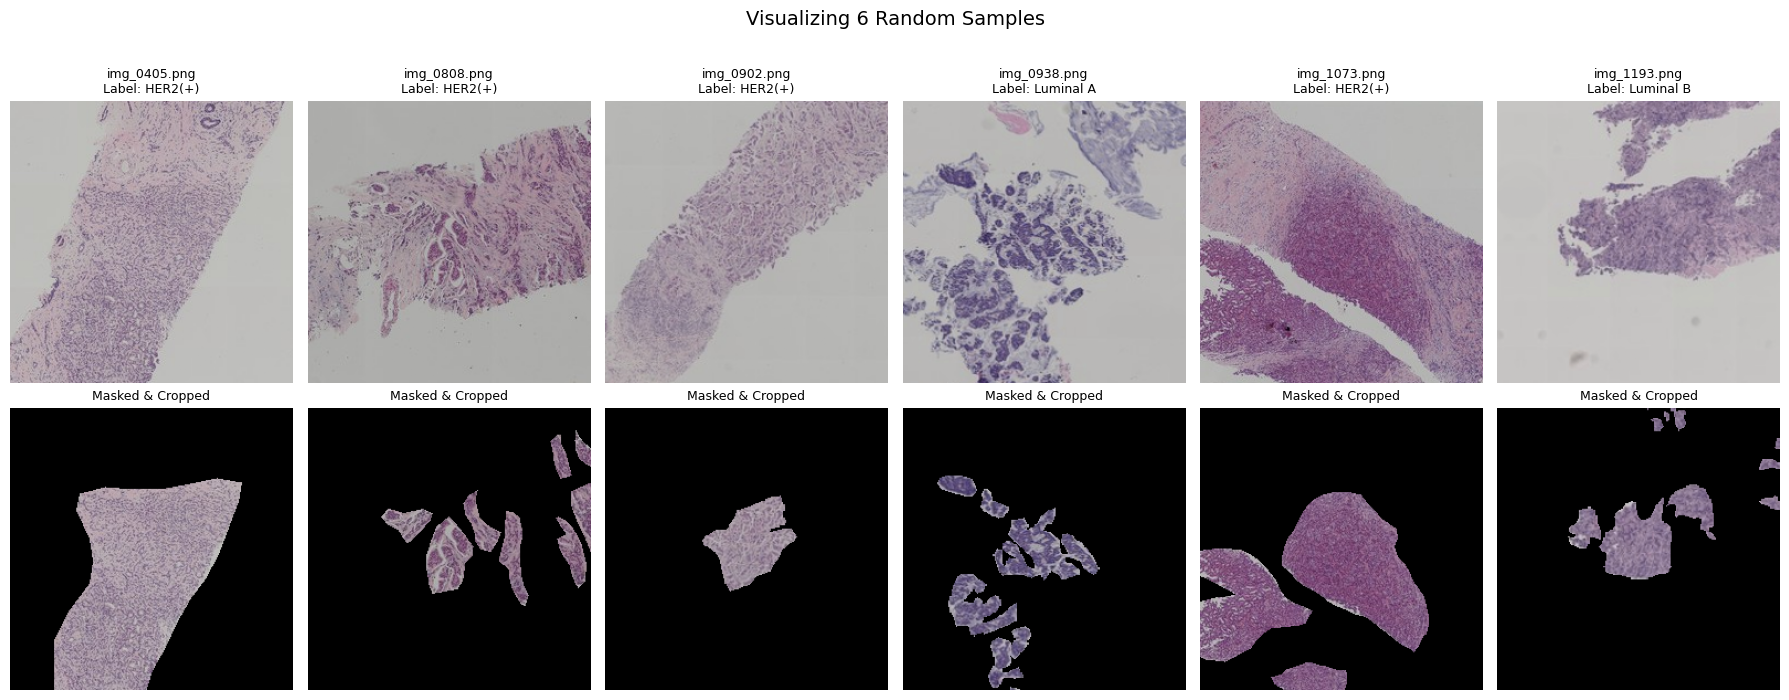

In [116]:
def make_loader(ds, batch_size, shuffle, drop_last):
    if os.name == 'nt': num = 0 
    else: num = min(8, os.cpu_count() or 2)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num, pin_memory=True)

def preprocess_inputs(images):
    tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)
    tensor = tensor / 255.0 
    return tensor

# 1. Load Training (Balanced)
train_cache = ('cache/train_img_bal.npy', 'cache/train_msk_bal.npy', 'cache/train_mkd_bal.npy')
raw_train, train_masks, train_images_masked, train_ids_patches = load_and_process_pipeline_multi_patch_balanced(
    TRAIN_DATA_PATH, TRAIN_LABEL_PATH, train_cache, WHITELIST_PATH, IMAGE_SIZE)

# 2. Load Test (Standard)
test_cache = (TEST_IMAGE_CACHE_PATH, TEST_MASKS_CACHE_PATH, TEST_MASKED_IMAGES_CACHE_PATH)
raw_test, test_masks, test_images_masked, test_ids_patches = load_and_process_pipeline_multi_patch(
    TEST_DATA_PATH, test_cache, None, IMAGE_SIZE)

# 3. Labels
unique_train_ids = sorted(list(set(train_ids_patches)), key=int)
original_labels = load_labels_aligned(TRAIN_LABEL_PATH, unique_train_ids)
label_map = dict(zip(unique_train_ids, original_labels))
train_labels_multi = np.array([label_map[uid] for uid in train_ids_patches])

# 4. Tensors
X_tensor = preprocess_inputs(train_images_masked)
label_encoder = LabelEncoder()
label_encoder.fit(original_labels)
y_encoded = label_encoder.transform(train_labels_aligned)
Y_tensor = torch.from_numpy(y_encoded).long()

# 5. Split (No Leakage)
patch_to_id = np.array(train_ids_patches)
unique_ids = np.unique(patch_to_id)
train_ids_split, val_ids_split = train_test_split(unique_ids, test_size=VALIDATION_SIZE, random_state=SEED, stratify=[label_map[uid] for uid in unique_ids])

train_mask = np.isin(patch_to_id, train_ids_split)
val_mask = np.isin(patch_to_id, val_ids_split)

train_ds = TensorDataset(X_tensor[train_mask], Y_tensor[train_mask])
val_ds   = TensorDataset(X_tensor[val_mask],   Y_tensor[val_mask])

train_loader = make_loader(train_ds, BATCH_SIZE, True, False)
val_loader   = make_loader(val_ds,   BATCH_SIZE, False, False)

# Info
print("-" * 30)
print(f"Train Patches: {len(train_ds)} | Val Patches: {len(val_ds)}")
print("-" * 30)

if PLOT_FLAG: 
    cplot.visualize_image_components(raw_train, train_masks, train_labels_multi, filenames=[f"img_{uid}.png" for uid in train_ids_patches], num_samples=6)

Visualizing distribution of 2140 generated patches...


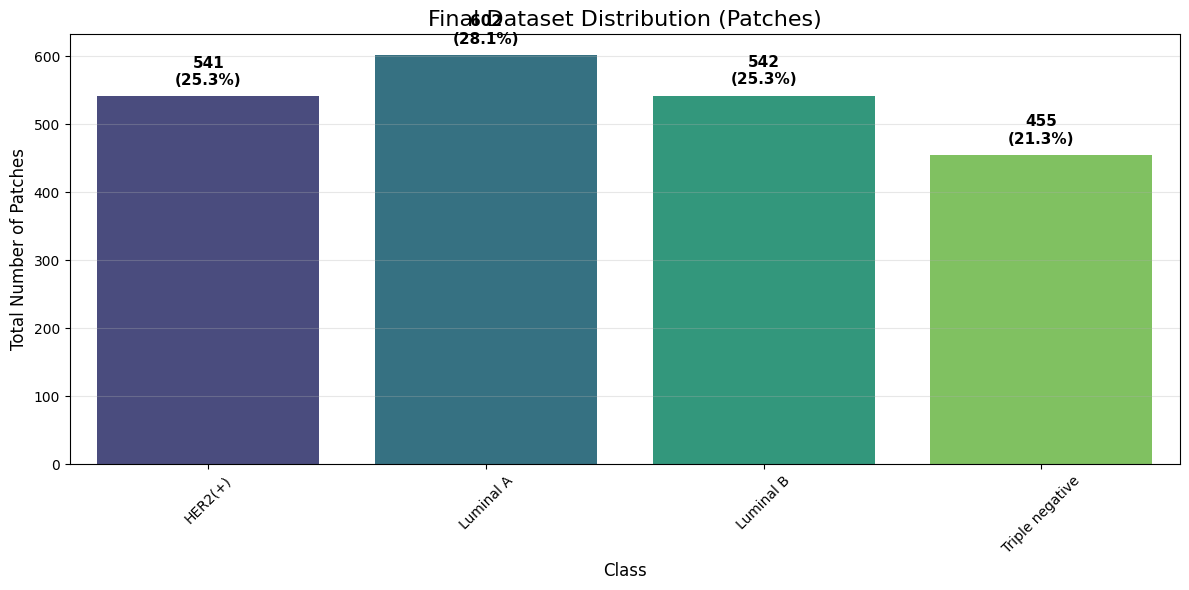

In [117]:
def plot_patch_distribution(labels, title="Final Dataset Distribution (Patches)"):

    # 1. Count classes
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # 2. Setup Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=unique_labels, y=counts, palette='viridis', hue=unique_labels, legend=False)
    
    # 3. Styling
    plt.title(title, fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Total Number of Patches", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # 4. Add count labels on top of bars
    total_patches = sum(counts)
    for i, v in enumerate(counts):
        percentage = (v / total_patches) * 100
        ax.text(i, v + (max(counts)*0.02), f"{v}\n({percentage:.1f}%)", 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
        
    plt.tight_layout()
    plt.show()

# Run the plot on the generated labels
print(f"Visualizing distribution of {len(train_labels_multi)} generated patches...")
plot_patch_distribution(train_labels_multi)

## Cross Entropy

In [118]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
CRITERION = nn.CrossEntropyLoss() # Standard CrossEntropy

## CNN Model

### Model Architecture

In [119]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

In [120]:
# %%
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet20, self).__init__()
        self.in_planes = 16

        # Initial Conv (3 -> 16 channels)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

### GradCam

In [121]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the layer to capture gradients and activations
        # We use a weakref to avoid memory leaks or issues with deepcopy if needed
        self.handles = []
        self.handles.append(target_layer.register_forward_hook(self.save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        self.model.eval()
        
        # Zero grads before starting
        self.model.zero_grad()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        # 2. Backward Pass
        score = logits[:, class_idx].squeeze()
        score.backward(retain_graph=True)
        
        # 3. Generate Map
        # Pool the gradients across the channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by the gradients
        # The activation map is usually (1, C, H, W)
        activation = self.activations[0]
        
        # Vectorized weighting is faster
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # Average the channels to get a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        
        # ReLU on top (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, logits

In [122]:
# %%
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2
from PIL import Image

def visualize_gradcam_with_mask_and_legend(model, images_tensor, masks_numpy, device, num_samples=3):
    """
    Plots: Original | Heatmap | GradCAM | Ground Truth Mask
    FIXED: Automatically detects the correct target layer for ResNet18 or ResNet20.
    """
    model.eval()
    
    # Define Normalization (Same as Val Transforms)
    norm_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

    # 1. Select Random Indices
    if len(images_tensor) < num_samples: num_samples = len(images_tensor)
    indices = np.random.choice(len(images_tensor), num_samples, replace=False)
    
    # Hooks
    gradients = None
    activations = None

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    # --- AUTO-DETECT TARGET LAYER ---
    if hasattr(model, 'layer4'):
        # ResNet18, ResNet34, ResNet50
        target_layer = model.layer4[-1]
    elif hasattr(model, 'layer3'):
        # ResNet20 (CIFAR style) or TinyResNet
        target_layer = model.layer3[-1]
    elif hasattr(model, 'features'):
        # SqueezeNet, VGG, MobileNet
        target_layer = model.features[-1]
    else:
        raise AttributeError("Could not automatically find the final convolutional layer. Check model architecture.")

    # Ensure gradients are enabled for the hook (in case model was frozen)
    for param in target_layer.parameters():
        param.requires_grad_(True)
        
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    # Create Plot Area
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1: axes = [axes] 

    for i, idx in enumerate(indices):
        # --- PREPARE INPUT ---
        raw_tensor = images_tensor[idx].unsqueeze(0).to(device)
        
        # Prepare for Model (Center Crop 224 -> Normalize)
        # Note: INPUT_SIZE variable must exist in global scope, usually 224
        input_tensor = transforms.CenterCrop(224)(raw_tensor)
        input_tensor = (input_tensor - norm_mean) / norm_std
        
        # Prepare for Plotting (Raw Image)
        plot_tensor = transforms.CenterCrop(224)(raw_tensor)
        original_img = plot_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        original_img = (original_img * 255).astype(np.uint8).copy()
        
        # --- MODEL PASS ---
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        
        score = output[:, pred_idx]
        score.backward()
        
        # --- GRAD-CAM ---
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]).cpu()
        act = activations.detach().cpu()
        
        for j in range(act.shape[1]):
            act[:, j, :, :] *= pooled_gradients[j]
            
        heatmap = torch.mean(act, dim=1).squeeze()
        heatmap = heatmap.detach().numpy() 
        
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        heatmap_uint8 = np.uint8(255 * heatmap)
        
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        superimposed_img = heatmap_color * 0.4 + original_img * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # --- MASK OVERLAY ---
        # Handle cases where masks_numpy might be None (pure inference)
        if masks_numpy is not None:
            gt_mask = masks_numpy[idx]
            gt_mask_pil = Image.fromarray(gt_mask)
            gt_mask_cropped = transforms.CenterCrop(224)(gt_mask_pil)
            gt_mask_cropped = np.array(gt_mask_cropped)
            
            mask_bool = np.any(gt_mask_cropped > 0, axis=-1)
            mask_overlay = original_img.copy()
            
            green_layer = np.zeros_like(original_img)
            green_layer[mask_bool] = [0, 255, 0] 
            
            if np.any(mask_bool):
                source = original_img[mask_bool].astype(np.float32)
                target = green_layer[mask_bool].astype(np.float32)
                blended = (source * 0.7) + (target * 0.3)
                mask_overlay[mask_bool] = blended.astype(np.uint8)
        else:
            mask_overlay = original_img # No mask available

        # --- PLOTTING ---
        axes[i][0].imshow(original_img)
        axes[i][0].set_title(f"Original (Center 224)\nSample {idx}")
        axes[i][0].axis('off')
        
        axes[i][1].imshow(heatmap_color)
        axes[i][1].set_title("Activation Heatmap")
        axes[i][1].axis('off')
        
        axes[i][2].imshow(superimposed_img)
        axes[i][2].set_title(f"Pred Class: {pred_idx}")
        axes[i][2].axis('off')

        axes[i][3].imshow(mask_overlay)
        axes[i][3].set_title("Ground Truth Mask\n(Green Area)")
        axes[i][3].axis('off')

    # --- ADD LEGEND ---
    plt.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    
    # Define ScalarMappable for the legend
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = cm.ScalarMappable(cmap=cm.jet, norm=norm)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Medium', 'High'])
    cbar.ax.tick_params(labelsize=12)

    handle_f.remove()
    handle_b.remove()
    plt.show()

### Data Augmentation

In [123]:
# --- Configuration (Standard 3-Channel) ---
INPUT_SIZE = 224

# ImageNet Stats (3 values for RGB only)
norm_mean = [0.485, 0.456, 0.406]  
norm_std = [0.229, 0.224, 0.225]   

# Define the Jitter/Randomization transforms (Excluding Normalization)
random_transforms = transforms.Compose([
    #transforms.CenterCrop(size=(INPUT_SIZE, INPUT_SIZE)),  # Changed from RandomCrop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
])

# Define the Jitter function (applies only to the 3 channels)
jitter_transform = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)


def transform_3_channel(inputs):
    """
    Applies spatial and color jitter to the 3-channel RGB tensor.
    Inputs shape: (N, 3, H, W)
    """
    # 1. Apply Spatial Randomization 
    inputs = random_transforms(inputs)
    
    # 2. Apply Color Jitter (Directly to the 3-channel tensor)
    inputs = jitter_transform(inputs)
    
    return inputs


# 1. Training Transforms (Apply Jitter + Spatial Randomization + Final Normalize)
train_transforms = transforms.Compose([
    transforms.Lambda(transform_3_channel), # Apply spatial/color augmentation
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# 2. Validation / Test Transforms (No jitter, just CenterCrop + Final Normalize)
val_transforms = transforms.Compose([
    #transforms.CenterCrop(size=(INPUT_SIZE, INPUT_SIZE)),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

### Training epoch

In [124]:

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # --- APPLY AUGMENTATION + NORMALIZATION ---
        # Inputs are [0, 1] here, so Augmentations work correctly.
        # Normalization happens at the end of the transform chain.
        inputs = train_transforms(inputs)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Regularization (Optional)
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

### Validating epoch

In [125]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # --- APPLY NORMALIZATION ONLY ---
            inputs = val_transforms(inputs)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_accuracy

In [126]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

### Training

In [127]:
# %%
# --- INITIALIZE RESNET20 (FROM SCRATCH) ---
vanilla_model = ResNet20(num_classes=len(label_encoder.classes_))

# Initialize Weights (Kaiming)
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

vanilla_model.apply(init_weights)
vanilla_model = vanilla_model.to(device)

# Optimizer (Higher LR because we are training from scratch)
optimizer = torch.optim.AdamW(vanilla_model.parameters(), lr=1e-3, weight_decay=1e-3)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

print("Initialized ResNet20 (Train From Scratch)")

# --- RUN TRAINING (Single Stage) ---
best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=150, # Needs more epochs than transfer learning
    criterion=CRITERION,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="resnet20_scratch",
    patience=20
)

print(f"Best Val F1: {max(history['val_f1']):.4f}")

Initialized ResNet20 (Train From Scratch)
Training 150 epochs...
Epoch   1/150 | Train: Loss=2.1486, F1 Score=0.2772 | Val: Loss=1.9184, F1 Score=0.0993
Epoch   2/150 | Train: Loss=1.4121, F1 Score=0.2996 | Val: Loss=1.4713, F1 Score=0.1877
Epoch   3/150 | Train: Loss=1.3759, F1 Score=0.2758 | Val: Loss=1.7355, F1 Score=0.1567
Epoch   4/150 | Train: Loss=1.3674, F1 Score=0.2829 | Val: Loss=1.5422, F1 Score=0.1250
Epoch   5/150 | Train: Loss=1.3594, F1 Score=0.3043 | Val: Loss=1.5429, F1 Score=0.1642
Epoch   6/150 | Train: Loss=1.3608, F1 Score=0.3121 | Val: Loss=1.4669, F1 Score=0.1900
Epoch   7/150 | Train: Loss=1.3605, F1 Score=0.3032 | Val: Loss=1.5966, F1 Score=0.1742
Epoch   8/150 | Train: Loss=1.3539, F1 Score=0.3043 | Val: Loss=1.4849, F1 Score=0.1703
Epoch   9/150 | Train: Loss=1.3376, F1 Score=0.3432 | Val: Loss=1.6498, F1 Score=0.2257
Epoch  10/150 | Train: Loss=1.3428, F1 Score=0.3413 | Val: Loss=2.0202, F1 Score=0.1416
Epoch  11/150 | Train: Loss=1.3558, F1 Score=0.3058 | V

In [128]:
# # %%
# # --- PHASE 1: WARMUP (Head Only) ---
# print("--- STARTING WARMUP (15 Epochs) ---")
# warmup_model, warmup_history = fit(
#     model=vanilla_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=15, 
#     criterion=CRITERION,
#     optimizer=optimizer,
#     scaler=scaler,
#     device=device,
#     writer=None,
#     verbose=1,
#     experiment_name="warmup",
#     patience=20
# )
# best_model = warmup_model

# # --- PHASE 2: FINE-TUNING (Unfreeze Deep Layers) ---
# print("\n--- WARMUP COMPLETE. STARTING FINE-TUNING ---")

# # 1. Unfreeze Last 2 Blocks (Layers 3 and 4)
# for name, child in best_model.named_children():
#     if name in ['layer3', 'layer4', 'fc']:
#         print(f"Unfreezing {name}...")
#         for param in child.parameters():
#             param.requires_grad = True
#     else:
#         for param in child.parameters():
#             param.requires_grad = False

# # 2. Re-create Optimizer with LOWER Learning Rate
# # We drop LR to 1e-4 to gently adjust the weights without breaking them
# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, best_model.parameters()), 
#     lr=1e-4, 
#     weight_decay=1e-3
# )

# # 3. Continue Training
# best_model, history_ft = fit(
#     model=best_model, # Continue with the warmed-up model
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=100, # Run longer for fine-tuning
#     criterion=CRITERION,
#     optimizer=optimizer,
#     scaler=scaler,
#     device=device,
#     experiment_name="finetune",
#     patience=20
# )

# final_val_f1 = round(max(history_ft['val_f1']), 2)
# print(f'Final validation F1 score: {final_val_f1}')

#### Plot Results

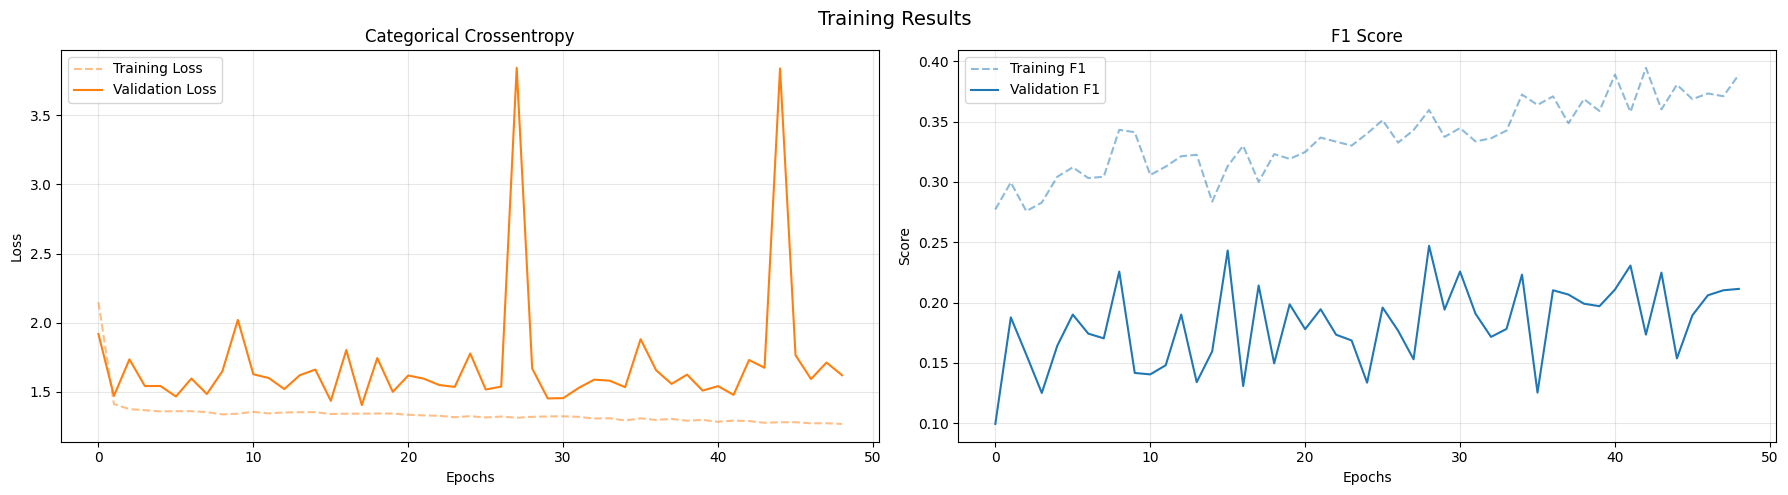

In [129]:
if PLOT_FLAG:
    cplot.plot_training_history(history, title=f"Training Results")

In [130]:
# --- STEP 2: FINE-TUNING (The Real Training) ---

# print("Warmup complete. Unfreezing layers 3 and 4 for fine-tuning...")

# # 1. Unfreeze Last 2 Blocks (Layers 3 and 4)
# # These are the layers that detect "Texture" and "Patterns"
# for name, child in vanilla_model.named_children():
#     if name in ['layer3', 'layer4', 'fc']:
#         print(f"Unfreezing {name}...")
#         for param in child.parameters():
#             param.requires_grad = True
#     else:
#         # Keep early layers frozen (they just detect edges, which are fine)
#         for param in child.parameters():
#             param.requires_grad = False

# # 2. Re-create Optimizer with LOWER Learning Rate
# # We use a smaller LR (1e-4) to gently update the weights without breaking them
# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, vanilla_model.parameters()), 
#     lr=1e-4, 
#     weight_decay=1e-3
# )

# # 3. Safety Check: Verify Data Range
# # If this prints negative values, STOP. (It means data is double-normalized)
# print(f"Data Check - Min: {X_tensor.min():.2f}, Max: {X_tensor.max():.2f} (Should be 0.00 to 1.00)")

# # 4. Continue Training
# best_model, history_ft = fit(
#     model=vanilla_model, # Continue with the warmed-up model
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=EPOCHS,
#     criterion=CRITERION,
#     optimizer=optimizer,
#     scaler=scaler,
#     device=device,
#     experiment_name="finetune",
#     patience=PATIENCE
# )

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import numpy as np
import torch

def plot_comprehensive_results(model, loader, device, label_encoder, history=None):
    """
    Plots:
    Row 1: Training History (Loss & F1)
    Row 2: Confusion Matrix | Class Distribution | Per-Class Metrics
    """
    print("Generating comprehensive evaluation plots...")
    
    # --- 1. Get Predictions ---
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in loader:
            # Handle tuple (inputs, labels)
            inputs = batch[0].to(device)
            labels = batch[1].to(device)
            
            # Forward pass
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
    class_names = label_encoder.classes_
    
    # --- 2. Setup Figure Grid ---
    # Wider figure to fit 3 plots in the second row
    fig = plt.figure(figsize=(24, 12)) 
    
    # GridSpec: 2 Rows, 6 Columns (allows us to split row 1 into 2 parts and row 2 into 3 parts)
    gs = fig.add_gridspec(2, 6) 

    # =======================================================
    # ROW 1: HISTORY (Span 3 columns each)
    # =======================================================
    if history:
        # Loss Plot (Top Left) -> Spans cols 0-3
        ax1 = fig.add_subplot(gs[0, 0:3])
        ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
        ax1.plot(history['val_loss'], label='Val Loss', color='tab:orange', linewidth=2)
        ax1.set_title("Loss Curves", fontsize=14)
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # F1 Score Plot (Top Right) -> Spans cols 3-6
        ax2 = fig.add_subplot(gs[0, 3:6])
        ax2.plot(history['train_f1'], label='Train F1', color='tab:green', linewidth=2)
        ax2.plot(history['val_f1'], label='Val F1', color='tab:red', linewidth=2)
        ax2.set_title("F1 Score Curves", fontsize=14)
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("F1 Score")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    else:
        ax1 = fig.add_subplot(gs[0, 0:3]); ax1.text(0.5, 0.5, "No History Provided", ha='center')
        ax2 = fig.add_subplot(gs[0, 3:6]); ax2.text(0.5, 0.5, "No History Provided", ha='center')

    # =======================================================
    # ROW 2: ANALYSIS (Span 2 columns each)
    # =======================================================
    
    # 1. Confusion Matrix (Bottom Left) -> Spans cols 0-2
    ax3 = fig.add_subplot(gs[1, 0:2])
    cm = confusion_matrix(all_targets, all_preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax3, cbar=False)
    
    ax3.set_title("Confusion Matrix", fontsize=14)
    ax3.set_xlabel("Predicted Label")
    ax3.set_ylabel("True Label")
    ax3.tick_params(axis='x', rotation=45)
    ax3.tick_params(axis='y', rotation=0)

    # 2. Prediction Distribution (Bottom Center) -> Spans cols 2-4
    ax4 = fig.add_subplot(gs[1, 2:4])
    unique_true, true_counts = np.unique(all_targets, return_counts=True)
    
    # Fill counts for all classes
    pred_counts_full = np.zeros(len(class_names))
    unique_pred, pred_counts = np.unique(all_preds, return_counts=True)
    for cls, count in zip(unique_pred, pred_counts):
        pred_counts_full[cls] = count

    # Ensure true_counts has entry for every class
    true_counts_full = np.zeros(len(class_names))
    for cls, count in zip(unique_true, true_counts):
        true_counts_full[cls] = count

    x = np.arange(len(class_names))
    width = 0.35
    
    ax4.bar(x - width/2, true_counts_full, width, label='Ground Truth', color='gray', alpha=0.6)
    ax4.bar(x + width/2, pred_counts_full, width, label='Predictions', color='tab:purple', alpha=0.9)
    
    ax4.set_title("Class Imbalance Check", fontsize=14)
    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names, rotation=45)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    # 3. Per-Class Metrics (Bottom Right) -> Spans cols 4-6
    ax5 = fig.add_subplot(gs[1, 4:6])
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=range(len(class_names)), zero_division=0
    )
    
    x = np.arange(len(class_names))
    width = 0.25

    rects1 = ax5.bar(x - width, precision, width, label='Precision', color='#87CEFA')
    rects2 = ax5.bar(x, recall, width, label='Recall', color='#90EE90')
    rects3 = ax5.bar(x + width, f1, width, label='F1', color='#F08080')

    ax5.set_title('Per-Class Metrics', fontsize=14)
    ax5.set_xticks(x)
    ax5.set_xticklabels(class_names, rotation=45)
    ax5.set_ylim(0, 1.15) # Extra space for labels
    ax5.legend(loc='lower right', fontsize='small')
    ax5.grid(axis='y', alpha=0.3)
    
    # Add value labels
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            # Only label if height > 0 to keep it clean
            if height > 0.01:
                ax5.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()

Generating comprehensive evaluation plots...


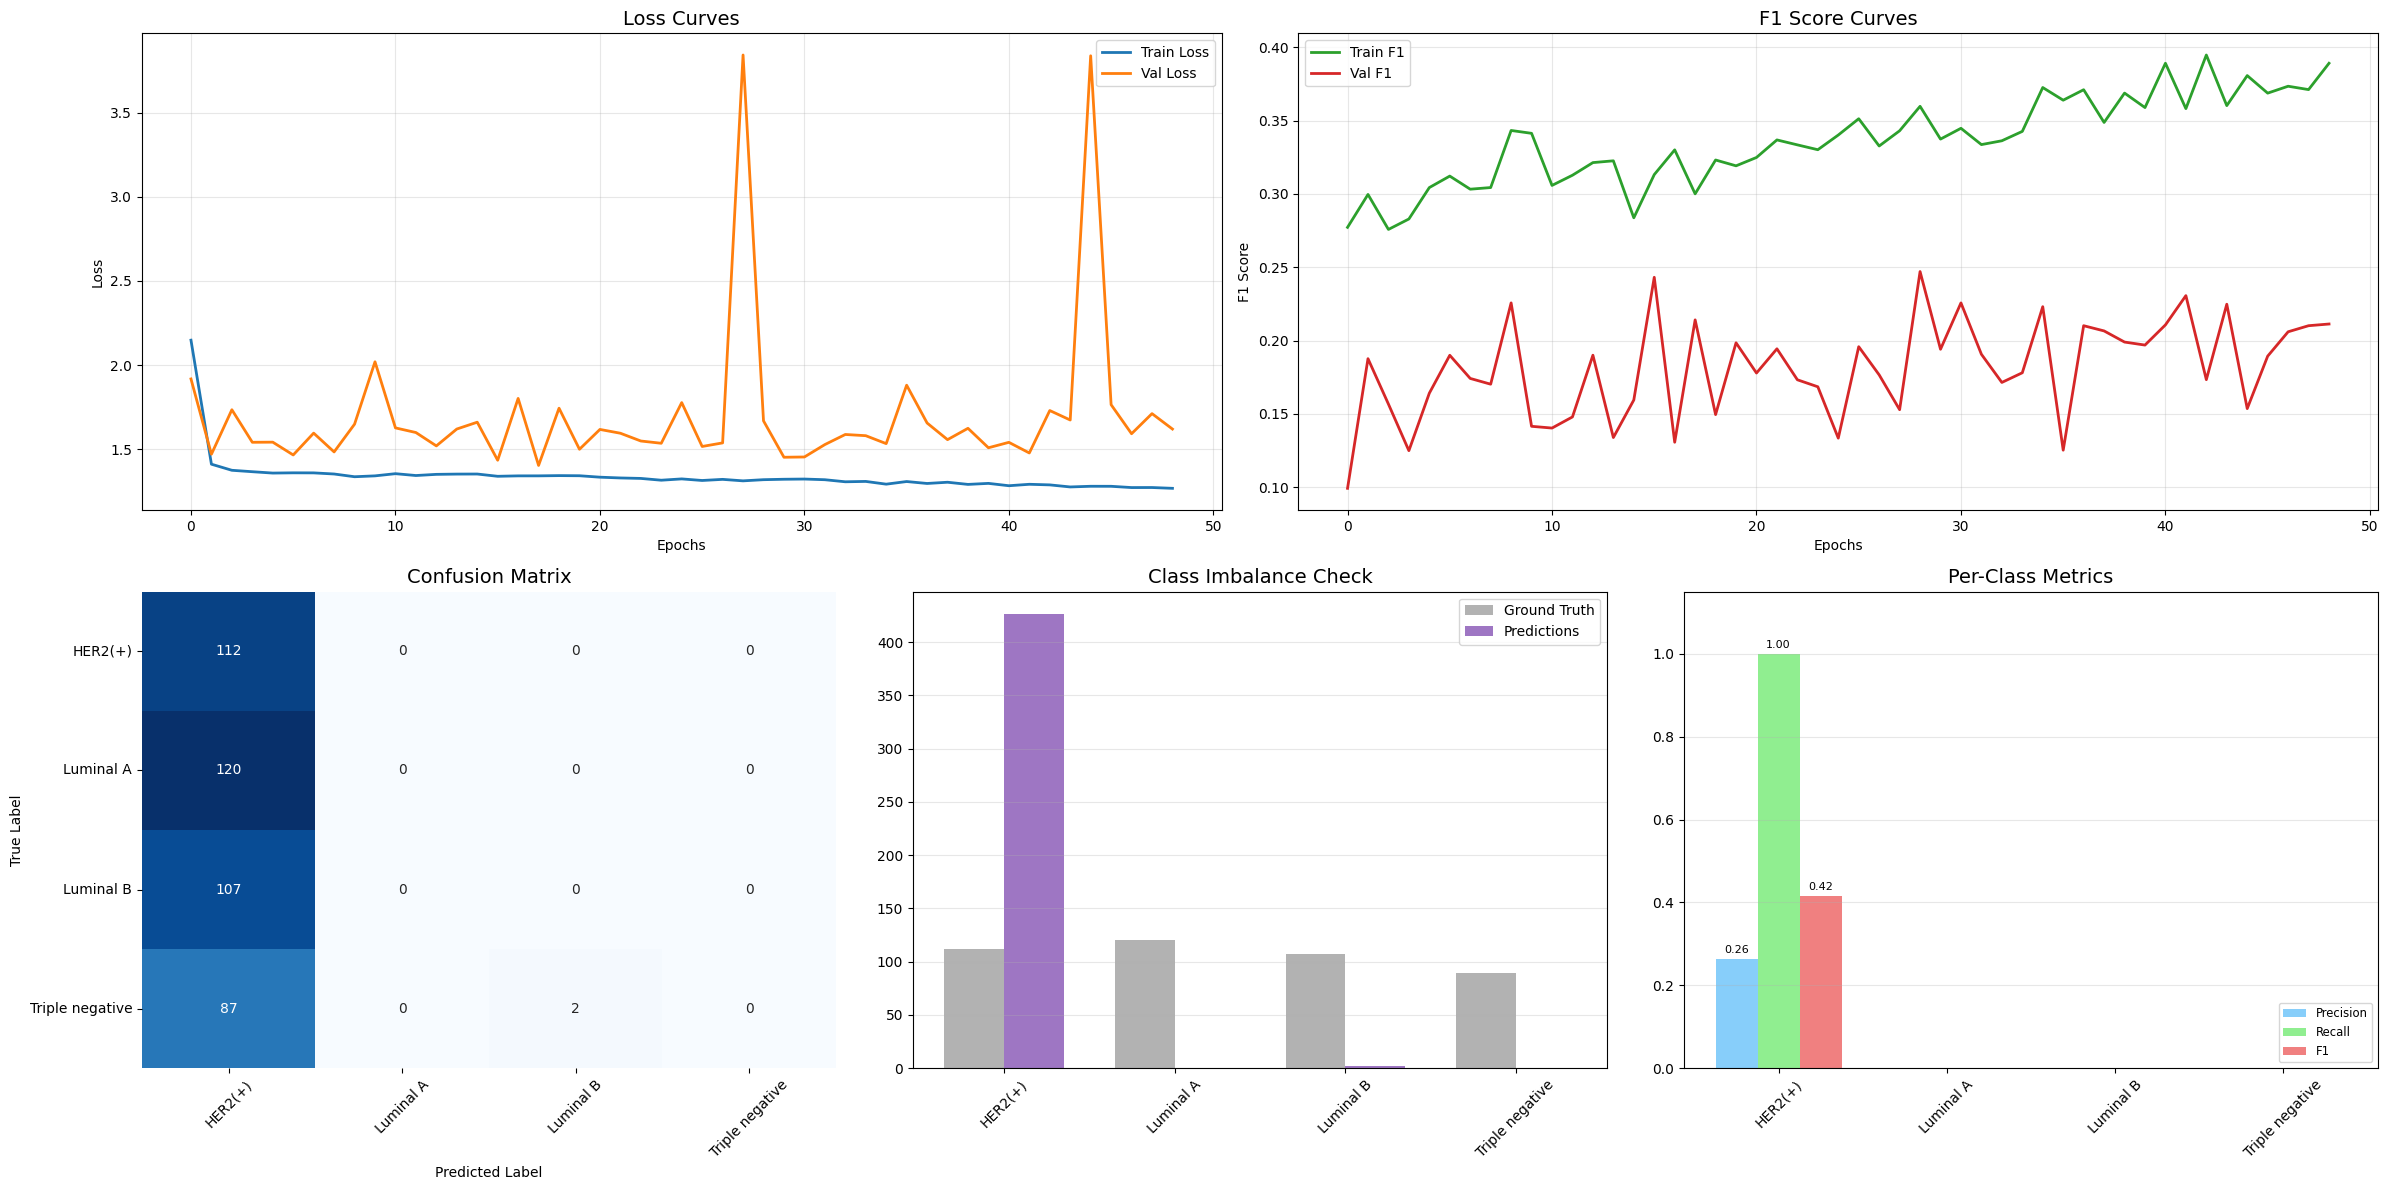

In [132]:
if PLOT_FLAG:
    plot_comprehensive_results(
    model=best_model,
    loader=val_loader,
    device=device,
    label_encoder=label_encoder,
    history=history
)

## Test Prediction

In [133]:

# --- 1. Define Test Transforms (MUST MATCH VALIDATION) ---
# We need to CenterCrop to 224 and Normalize, just like we did for Val.
test_transforms = transforms.Compose([
    #transforms.CenterCrop(size=(INPUT_SIZE, INPUT_SIZE)), # Crop 224 from 512
    transforms.Normalize(mean=norm_mean, std=norm_std)
])


def get_predictions(model, loader, device):
    print(f"--- Starting Inference on {len(loader.dataset)} Samples ---")
    model.eval()
    all_predictions = []
    
    # Standard stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    # Create TenCrop separately
    cropper = transforms.TenCrop(size=INPUT_SIZE)
    
    with torch.no_grad():
        for batch in loader:
            # Inputs: (Batch, 3, 224, 224)
            # Ensure it is a tensor
            inputs = batch[0] if isinstance(batch, (list, tuple)) else batch
            
            # --- MANUAL TTA LOOP ---
            batch_preds = []
            
            for i in range(inputs.size(0)):
                img = inputs[i] # (3, 224, 224)
                
                # 1. Generate 10 Crops (Returns tuple of 10 tensors)
                crops = cropper(img) 
                
                # 2. Stack into (10, 3, 224, 224)
                crops_tensor = torch.stack(crops).to(device)
                
                # 3. Normalize manually on GPU (Safe & Fast)
                crops_tensor = (crops_tensor - mean) / std
                
                # 4. Forward Pass
                with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                    logits = model(crops_tensor) # (10, Num_Classes)
                
                # 5. Average logits across crops
                avg_logit = logits.mean(dim=0) # (Num_Classes)
                
                # 6. Get Class
                pred = avg_logit.argmax().item()
                batch_preds.append(pred)
            
            all_predictions.extend(batch_preds)
            
    print("Inference complete.")
    return np.array(all_predictions)




In [134]:
# %%
def create_submission_csv(predictions, filenames_original, image_ids_patches, encoder, output_csv="submission.csv"):
    
    # Check 1: Ensure we have one image ID for every single prediction
    if len(predictions) != len(image_ids_patches):
         raise ValueError("Internal Error: Prediction array must match the patch ID array length.")

    # 1. Create DataFrame of predictions
    df_preds = pd.DataFrame({
        'image_id': image_ids_patches,
        'prediction': predictions
    })
    
    # --- FIX 1: Ensure image_id is INTEGER ---
    df_preds['image_id'] = df_preds['image_id'].astype(int)
    
    # 2. Group by image ID and find the Mode (Majority Vote)
    final_labels_raw = df_preds.groupby('image_id')['prediction'].agg(
        lambda x: x.mode().iloc[0]
    ).reset_index()
    
    # 3. Align Final Labels with the Original Filenames List
    df_filenames = pd.DataFrame({'sample_index': filenames_original})
    
    # Extract ID and --- FIX 2: Convert to INTEGER ---
    df_filenames['image_id'] = df_filenames['sample_index'].str.split('_').str[1].str.split('.').str[0].astype(int)
    
    # 4. Merge
    # Now that both columns are Integers, 1 will match 001.
    submission_df = df_filenames.merge(
        final_labels_raw, 
        on='image_id', 
        how='left'
    ).drop(columns=['image_id'])

    # 5. Final Conversion and Save
    # Handle any NaNs that might occur if a file was missed (fill with class 0)
    if submission_df['prediction'].isnull().any():
        print("Warning: Some images were missing predictions. Filling with 0.")
        submission_df['prediction'] = submission_df['prediction'].fillna(0)

    final_predictions_encoded = submission_df['prediction'].values
    
    print(f"Decoding {len(final_predictions_encoded)} labels...")
    predicted_labels = encoder.inverse_transform(final_predictions_encoded.astype(int))
    
    submission_df['label'] = predicted_labels
    submission_df = submission_df[['sample_index', 'label']]
    
    submission_df.to_csv(output_csv, index=False)
    print(f"Saved submission to '{output_csv}'")
    print(submission_df.head())
    
    return submission_df

In [135]:
def plot_test_distribution(submission_df):
    plt.figure(figsize=(10, 6))
    
    # Count the predicted labels
    counts = submission_df['label'].value_counts()
    
    # Plot bar chart
    ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)
    
    plt.title("Test Set Prediction Distribution", fontsize=15)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Add numbers on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
        
    plt.tight_layout()
    plt.show()

Preprocessing Test Data...
Test Shape: torch.Size([3, 256, 256]) | Samples: 2743
Visualizing TEST Data Focus...


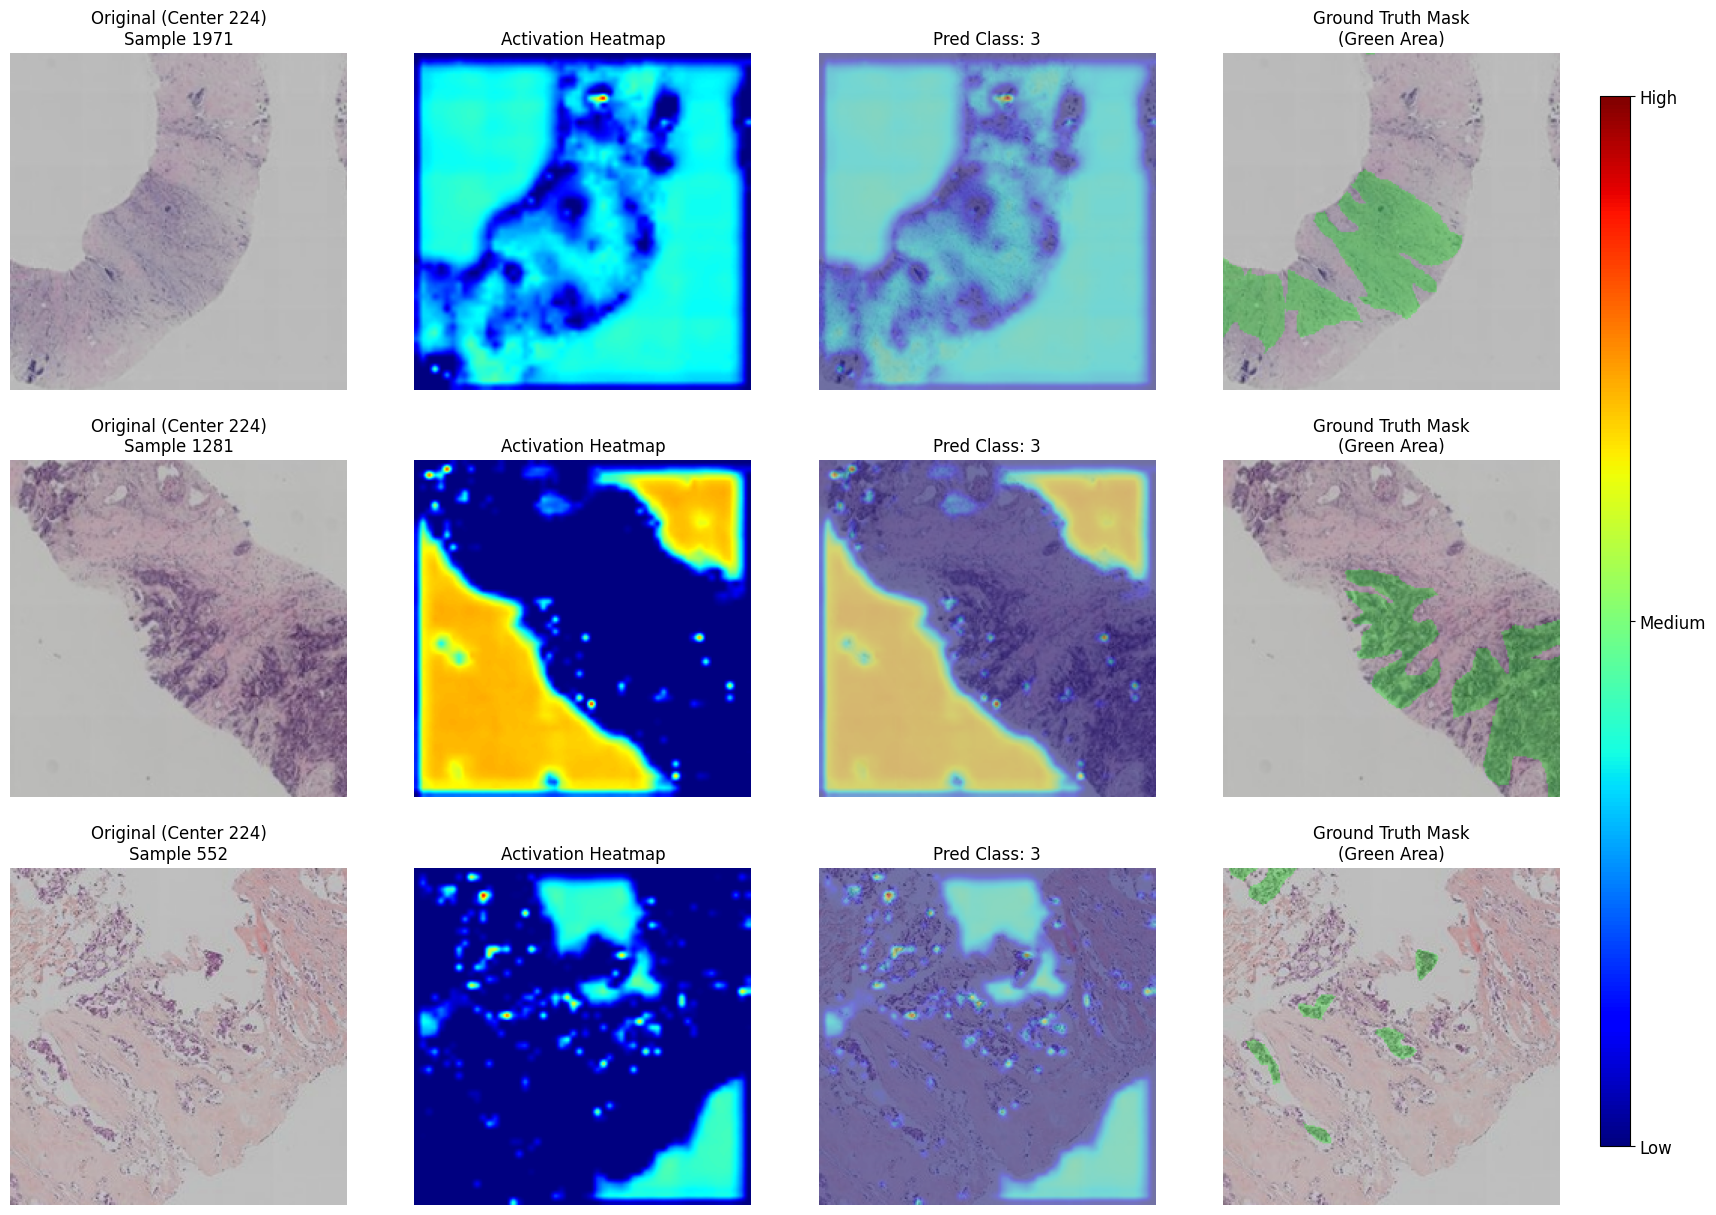

--- Starting Inference on 2743 Samples ---
Inference complete.
Decoding 954 labels...
Saved submission to 'submission.csv'
   sample_index            label
0  img_0000.png  Triple negative
1  img_0001.png  Triple negative
2  img_0002.png  Triple negative
3  img_0003.png        Luminal A
4  img_0004.png        Luminal A


In [136]:
# %%
print("Preprocessing Test Data...")
# Ensure we are using the Test cache
X_test_tensor = preprocess_inputs(test_images_masked)
test_ds = TensorDataset(X_test_tensor)

# Create Test Loader
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_filenames = get_sorted_filenames(TEST_DATA_PATH)

print(f"Test Shape: {test_ds[0][0].shape} | Samples: {len(test_ds)}")

# --- 4. VISUALIZATION (FIXED) ---
if 'best_model' not in locals() or best_model is None:
    print("Warning: best_model not found, using vanilla_model.")
    best_model = vanilla_model

print("Visualizing TEST Data Focus...")
# CALLING THE VISUALIZATION FUNCTION HERE
visualize_gradcam_with_mask_and_legend(
    model=best_model,           
    images_tensor=X_test_tensor,  
    masks_numpy=test_masks,       
    device=device,
    num_samples=3
)

# --- 5. Run Inference ---
raw_predictions = get_predictions(best_model, test_loader, device)

# 2. Generate Submission (using the correct multi-patch arguments)
submission_df  = create_submission_csv(
    predictions=raw_predictions,
    filenames_original=test_filenames,        # List of img_001.png, img_002.png...
    image_ids_patches=test_ids_patches,       # List of '1', '1', '1', '2', '2', '3'...
    encoder=label_encoder,
    output_csv="submission.csv"
)


Checking Prediction Balance...


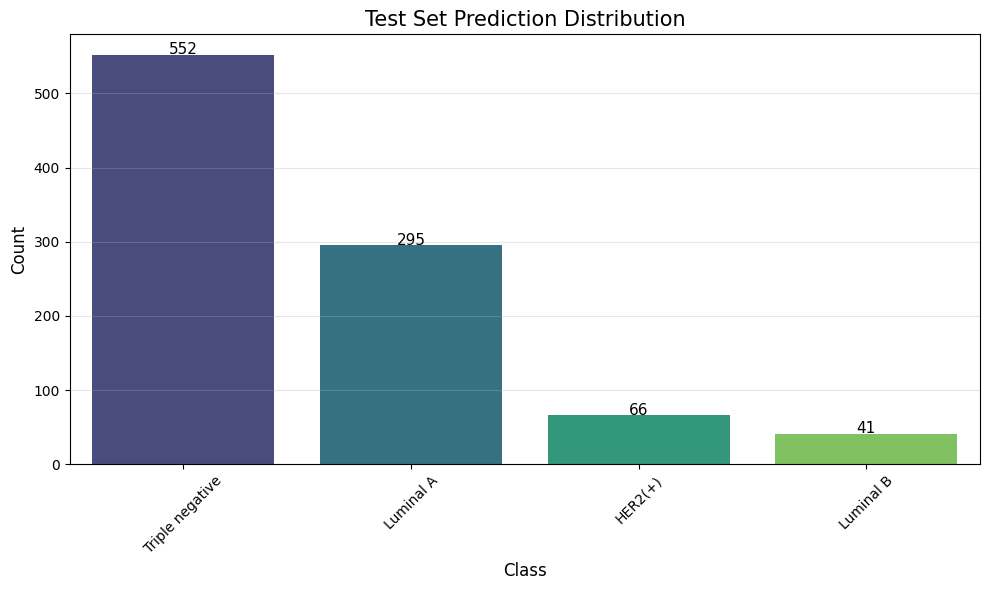

In [137]:
print("\nChecking Prediction Balance...")
plot_test_distribution(submission_df)